# Model-lr&svm

In [1]:
import numpy as np
import pandas as pd
from prepare_data import prepare_data
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve,accuracy_score, recall_score, precision_score, f1_score
from sklearn import svm
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
# maximize the display of columns in pandas dataframe
pd.set_option('display.max_columns', None)

## Step 1. Load data

The preprocessing we choose for logistic regression is
+ standardization

In [2]:
# load and prepare the data
# rescale the features using standardization (z-score normalization) since we are using logistic regression, which can benefit from features being on a similar scale.
train_df, val_df,test_df, unlabeled_df = prepare_data(
    filepaths=["../data/O012791.npz", "../data/O013257.npz", "../data/O013490.npz"],
    coord_cols=["y_coord", "x_coord"],
    image_col="image_id",
    label_col="label",
    train_images=["O013490"],
    val_images=["O012791"],
    test_images=["O013257"],
    labeled_only=True,
    map_label_to_binary=True,
    scaler_type = 'standard'  ,  # "standard", "robust", or None,
    remove_outliers = False,
    outlier_threshold = 3.0
)

print("Train set shape:", train_df.shape)
print("Train label distribution:\n", train_df['label'].value_counts(normalize=True))
print("Val set shape:", val_df.shape)
print("Val label distribution:\n", val_df['label'].value_counts(normalize=True))
print("Test set shape:", test_df.shape)
print("Test label distribution:\n", test_df['label'].value_counts(normalize=True))

Loading data from 3 files...
Merging engineered features...
Successfully merged engineered features from ../data/O013490.csv for image O013490.
After merging, O013490 has 115032 rows and 116 columns.
Successfully merged engineered features from ../data/O012791.csv for image O012791.
After merging, O012791 has 114973 rows and 116 columns.
Successfully merged engineered features from ../data/O013257.csv for image O013257.
After merging, O013257 has 115000 rows and 116 columns.
Finished merging engineered features. Train shape: (115032, 116), Val shape: (114973, 116), Test shape: (115000, 116)
Preparing data...
Train set shape: (82083, 116)
Train label distribution:
 label
0    0.521789
1    0.478211
Name: proportion, dtype: float64
Val set shape: (54772, 116)
Val label distribution:
 label
0    0.612138
1    0.387862
Name: proportion, dtype: float64
Test set shape: (70826, 116)
Test label distribution:
 label
0    0.71101
1    0.28899
Name: proportion, dtype: float64


In [3]:
train_df.describe()

,y_coord,x_coord,NDAI,SD,CORR,radiance_DF,radiance_CF,radiance_BF,radiance_AF,radiance_AN,label,NDAI_3_min,NDAI_3_mean,NDAI_3_max,SD_3_min,SD_3_mean,SD_3_max,CORR_3_min,CORR_3_mean,CORR_3_max,DF_3_min,DF_3_mean,DF_3_max,CF_3_min,CF_3_mean,CF_3_max,BF_3_min,BF_3_mean,BF_3_max,AF_3_min,AF_3_mean,AF_3_max,AN_3_min,AN_3_mean,AN_3_max,NDAI_5_min,NDAI_5_mean,NDAI_5_max,SD_5_min,SD_5_mean,SD_5_max,CORR_5_min,CORR_5_mean,CORR_5_max,DF_5_min,DF_5_mean,DF_5_max,CF_5_min,CF_5_mean,CF_5_max,BF_5_min,BF_5_mean,BF_5_max,AF_5_min,AF_5_mean,AF_5_max,AN_5_min,AN_5_mean,AN_5_max,NDAI_9_min,NDAI_9_mean,NDAI_9_max,SD_9_min,SD_9_mean,SD_9_max,CORR_9_min,CORR_9_mean,CORR_9_max,DF_9_min,DF_9_mean,DF_9_max,CF_9_min,CF_9_mean,CF_9_max,BF_9_min,BF_9_mean,BF_9_max,AF_9_min,AF_9_mean,AF_9_max,AN_9_min,AN_9_mean,AN_9_max,NDAI_13_min,NDAI_13_mean,NDAI_13_max,SD_13_min,SD_13_mean,SD_13_max,CORR_13_min,CORR_13_mean,CORR_13_max,DF_13_min,DF_13_mean,DF_13_max,CF_13_min,CF_13_mean,CF_13_max,BF_13_min,BF_13_mean,BF_13_max,AF_13_min,AF_13_mean,AF_13_max,AN_13_min,AN_13_mean,AN_13_max,ae0,ae1,ae2,ae3,ae4,ae5,ae6,ae7
count,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000,82083.000000
mean,187.817392,218.414861,0.087049,-0.246811,-0.217766,-0.083120,-0.090931,-0.102142,-0.114387,-0.115566,0.478211,0.140332,0.088831,0.039107,-0.212740,-0.267747,-0.287098,-0.229203,-0.249791,-0.237948,-0.014437,-0.086534,-0.158961,-0.025653,-0.093817,-0.166978,-0.043545,-0.103980,-0.166136,-0.059082,-0.115797,-0.172909,-0.060105,-0.117013,-0.173442,0.165448,0.089485,0.017522,-0.162635,-0.279703,-0.314381,-0.227762,-0.262578,-0.244073,0.015868,-0.090501,-0.204612,0.001627,-0.096850,-0.211838,-0.017566,-0.105675,-0.202333,-0.033865,-0.116968,-0.206298,-0.035160,-0.118225,-0.206400,0.189275,0.089190,-0.005019,-0.069288,-0.290297,-0.341735,-0.209438,-0.272021,-0.247393,0.038776,-0.098890,-0.258016,0.023006,-0.102671,-0.269997,0.006455,-0.108656,-0.250481,-0.008473,-0.118807,-0.250991,-0.009647,-0.120088,-0.250812,0.199372,0.088298,-0.015317,-0.003811,-0.291440,-0.343173,-0.189669,-0.273526,-0.244000,0.045174,-0.106520,-0.276844,0.031376,-0.107434,-0.300096,0.018168,-0.110678,-0.277277,0.004936,-0.119698,-0.276668,0.004231,-0.121088,-0.276752,0.112578,0.077668,0.061774,0.068249,-0.078810,-0.163551,-0.319850,0.000482
std,116.484000,92.566690,1.101591,0.758048,0.982366,0.990781,1.036485,1.067208,1.076291,1.078613,0.499528,1.089839,1.112144,1.108730,0.806844,0.774557,0.750613,0.955658,0.965020,0.995939,1.009429,1.005755,0.979515,1.044438,1.050572,1.020120,1.072214,1.077042,1.050450,1.085

In [4]:
feature_cols = [ col for col in train_df.columns if col not in ['label', 'y_coord', 'x_coord', 'image_id'] ]
X_train = train_df[feature_cols]
y_train = train_df["label"]
X_val = val_df[feature_cols]
y_val = val_df["label"]
X_test = test_df[feature_cols]
y_test = test_df["label"]

In [5]:
X_train.sample(n=5)

,NDAI,SD,CORR,radiance_DF,radiance_CF,radiance_BF,radiance_AF,radiance_AN,NDAI_3_min,NDAI_3_mean,NDAI_3_max,SD_3_min,SD_3_mean,SD_3_max,CORR_3_min,CORR_3_mean,CORR_3_max,DF_3_min,DF_3_mean,DF_3_max,CF_3_min,CF_3_mean,CF_3_max,BF_3_min,BF_3_mean,BF_3_max,AF_3_min,AF_3_mean,AF_3_max,AN_3_min,AN_3_mean,AN_3_max,NDAI_5_min,NDAI_5_mean,NDAI_5_max,SD_5_min,SD_5_mean,SD_5_max,CORR_5_min,CORR_5_mean,CORR_5_max,DF_5_min,DF_5_mean,DF_5_max,CF_5_min,CF_5_mean,CF_5_max,BF_5_min,BF_5_mean,BF_5_max,AF_5_min,AF_5_mean,AF_5_max,AN_5_min,AN_5_mean,AN_5_max,NDAI_9_min,NDAI_9_mean,NDAI_9_max,SD_9_min,SD_9_mean,SD_9_max,CORR_9_min,CORR_9_mean,CORR_9_max,DF_9_min,DF_9_mean,DF_9_max,CF_9_min,CF_9_mean,CF_9_max,BF_9_min,BF_9_mean,BF_9_max,AF_9_min,AF_9_mean,AF_9_max,AN_9_min,AN_9_mean,AN_9_max,NDAI_13_min,NDAI_13_mean,NDAI_13_max,SD_13_min,SD_13_mean,SD_13_max,CORR_13_min,CORR_13_mean,CORR_13_max,DF_13_min,DF_13_mean,DF_13_max,CF_13_min,CF_13_mean,CF_13_max,BF_13_min,BF_13_mean,BF_13_max,AF_13_min,AF_13_mean,AF_13_max,AN_13_min,AN_13_mean,AN_13_max,ae0,ae1,ae2,ae3,ae4,ae5,ae6,ae7
29322,0.569261,0.414579,0.175714,-1.508238,-1.444072,-1.484130,-1.362660,-1.349950,0.921888,0.916103,1.102994,0.671453,0.480685,0.360448,-0.244208,-0.115238,-0.175729,-0.988192,-1.294906,-1.532611,-1.149088,-1.471539,-1.719707,-1.267100,-1.572765,-1.823083,-1.256064,-1.467839,-1.669916,-1.531885,-1.496220,-1.649739,1.164805,1.126894,1.246198,1.008192,0.563707,0.272566,-0.095554,-0.339083,-0.608201,-0.762435,-1.318241,-1.515194,-1.129445,-1.626786,-1.918183,-1.194701,-1.624695,-1.976392,-1.257725,-1.589619,-1.875724,-1.492847,-1.642617,-1.842626,0.672378,1.358682,1.447384,0.964441,0.696221,0.116829,-0.243146,-0.604967,-0.695499,-0.620186,-1.207340,-1.177886,-1.172274,-1.806434,-1.805843,-1.495881,-1.726408,-1.840914,-1.466671,-1.736636,-1.198976,-1.434364,-1.729138,-1.200469,0.608704,1.434567,1.465651,1.474881,0.828925,0.025009,-0.056160,-0.489052,-0.237225,-0.385883,-1.082598,-0.618733,-0.909175,-1.721266,-1.181053,-1.373863,-1.780611,-1.154952,-1.386451,-1.738454,-0.507031,-1.361880,-1.691824,-0.243311,1.351672,-0.616778,-0.028737,0.015999,0.882407,-1.427407,-0.147104,0.397891
15546,1.291586,1.433225,-0.431902,-0.460315,-1.336302,-1.743247,-1.969107,-1.469318,1.059533,1.326622,1.303235,2.555452,1.573543,0.957643,-0.621313,-1.041628,-1.456001,-0.816224,-0.772831,-0.790920,-1.021976,-1.290342,-1.513344,-1.486214,-1.707729,-1.875947,-1.651670,-1.728529,-1.478945,-1.510194,-1.586930,-1.320378,1.019288,1.531140,1.522525,2.630727,1.522934,0.902511,-0.682370,-1.182101,-1.992376,-0.578183,-0.765867,-0.552849,-0.879167,-1.375500,-1.674759,-1.370971,-1.700048,-1.796323,-1.515148,-1.680088,-1.428095,-1.539436,-1.714236,-1.281669,1.375631,1.861172,1.503743,3.482813,1.253681,0.497343,-0.404786,-1.159412,-1.928698,-0.331260,-0.741780,-0.788645,-0.822285,-1.453603,-1.964053,-1.178414,-1.652181,-1.648878,-1.385928,-1.791558,-1.551496,-1.430128,-1.909233,-1.432390,1.645231,2.125666,1.816599,2.923354,1.208955,0.258888,-0.147842,-1.117583,-2.436370,-0.273359,-0.715479,-0.744504,-0.832685,-1.498401,-1.880874,-1.656423,-1.742897,-1.872888,-1.676781,-1.932295,-1.753134,-1.632049,-2.050827,-1.619379,1.779810,-1.889646,0.667610,-0.745915,0.513822,-1.437055,-0.021605,0.966414
103033,-0.923852,-0.843098,-0.076800,-0.162380,0.433500,0.756818,0.866403,0.876530,-0.810520,-0.940022,-0.992149,-0.882161,-0.925012,-0.912323,-0.893910,-0.265537,0.434644,0.105316,-0.148988,-0.418236,0.585411,0.451609,0.238865,0.854359,0.775618,0.632976,0.947742,0.877759,0.753412,0.956524,0.887300,0.759932,-0.699815,-0.950450,-1.035416,-0.894469,-0.980308,-0.962825,-0.558362,-0.319377,0.124029,0.265199,-0.144973,-0.598001,0.670813,0.460586,0.080457,0.901100,0.783738,0.535856,0.974447,0.882267,0.669395,0.983985,0.892236,0.677343,-0.499556,-0.962379,-1.075404,-0.872505,-1.049480,-1.019179,-0.167207,-0.036777,0.805636,0.456224,-0.132675,-0.804972,0.776415,0.481445,-0.160537,0.964770,0.797290,0.374176,1.028468,0.890518,0.527689,

In [6]:
X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape

((82083, 112), (82083,), (54772, 112), (54772,), (70826, 112), (70826,))

In [7]:
# define helper function to evaluate the model on training and validation sets
def evaluate_model(y, prob, threshold=0.5, pred = None):
    if pred is None:
        pred = (prob >= threshold).astype(int)

    print('Evaluation:')
    print(classification_report(y, pred))
    print('Confusion Matrix:')
    print(confusion_matrix(y, pred))

    results = {
        "accuracy": accuracy_score(y, pred),
        "recall": recall_score(y, pred),
        "precision": precision_score(y, pred),
        "f1_score": f1_score(y, pred),
        "auc": roc_auc_score(y, prob)
    }
    return results


In [8]:
# helper function to save the results
import os
import json
def save_pipeline_results(results, output_dir):
    os.makedirs(output_dir, exist_ok=True)

    metrics_df = pd.DataFrame([
        {"dataset": "train", **results["train_results"]},
        {"dataset": "val", **results["val_results"]},
        {"dataset": "test", **results["test_results"]},
    ])
    metrics_df.to_csv(os.path.join(output_dir, "metrics_summary.csv"), index=False)

    pd.DataFrame({"feature": results["selected_features"]}).to_csv(
        os.path.join(output_dir, "selected_features.csv"),
        index=False
    )
    # Keep a git-friendly artifact for reproducibility when CSV files are ignored.
    with open(os.path.join(output_dir, "selected_features.json"), "w") as f:
        json.dump(results["selected_features"], f, indent=2)
        
    results["tuning_df"].to_csv(
        os.path.join(output_dir, "tuning_results.csv"),
        index=False
    )

    metadata = {
        "best_model_params": results["best_model_params"],
        "best_model_threshold": results["best_model_threshold"],
        "best_model_score": results["best_model_score"],
        "data_params": results["data_params"],
        "feature_selection_used": results["feature_selection_used"],
        "feature_selection_params": results["feature_selection_params"],
    }

    with open(os.path.join(output_dir, "run_metadata.json"), "w") as f:
        json.dump(metadata, f, indent=2, default=str)

## Step 2. Feature selection

In all, we have got 112 features. I will do a basic feature selection first with some basic statistical properties and then find an optimal feature set with advanced model-driven method.

### 2.1 Remove near-zero variance features

In [9]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=1e-5) # set a very low threshold to remove only features with near-zero variance
X_variance_selected = selector.fit_transform(X_train)
selected_var_cols = X_train.columns[selector.get_support()]

In [10]:
print("Number of features before variance thresholding:", X_train.shape[1])
print("Number of features after variance thresholding:", X_variance_selected.shape[1])

Number of features before variance thresholding: 112
Number of features after variance thresholding: 112


### 2.2 Remove highly-correlated features

In [11]:
corr = X_train[selected_var_cols].corr().abs()
upper = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)
corr_to_drop = [
    column for column in upper.columns
    if any(upper[column] > 0.95)
]

In [12]:
len(corr_to_drop), corr_to_drop[:10]

(72,
 ['radiance_AF',
  'radiance_AN',
  'NDAI_3_min',
  'NDAI_3_mean',
  'NDAI_3_max',
  'SD_3_mean',
  'SD_3_max',
  'DF_3_mean',
  'CF_3_mean',
  'CF_3_max'])

In [13]:
X_selected = X_train[selected_var_cols].drop(columns=corr_to_drop)

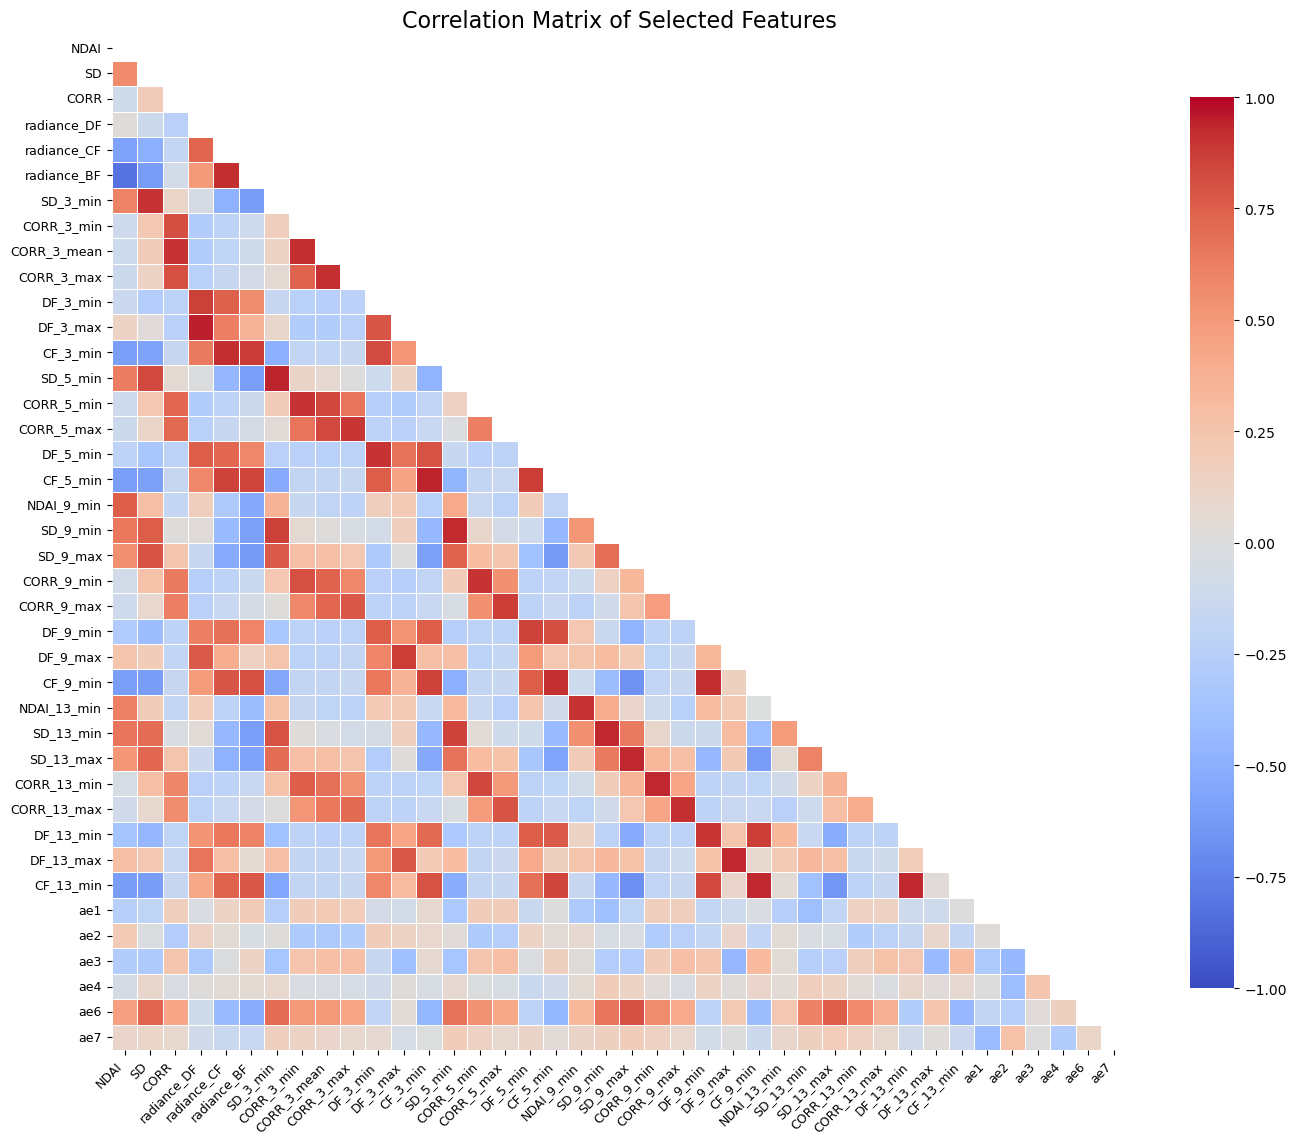

In [14]:
# visualize the correlation matrix of the remaining features
corr = X_selected.corr()
# mask upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 12))

sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix of Selected Features", fontsize=16)

plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(fontsize=9)

plt.tight_layout()
plt.show()

### 2.3 Univariate thresholding

I use mutual information as the selection metrics:

$$
I(X,Y) = D_{KL}(P(X,Y) \| P_X \otimes P_Y)
$$
where $D_{\mathrm {KL} }$ is the Kullback–Leibler divergence, and 
${\displaystyle P_{X}\otimes P_{Y}}$ is the outer product distribution which assigns probability 
${\displaystyle P_{X}(x)\cdot P_{Y}(y)}$ to each ${\displaystyle (x,y)}$.

Notice, as per property of the Kullback–Leibler divergence, that ${\displaystyle I(X;Y)}$ is equal to zero precisely when the joint distribution coincides with the product of the marginals, i.e. when 
${\displaystyle X}$ and ${\displaystyle Y}$ are independent (and hence observing ${\displaystyle Y}$ tells you nothing about ${\displaystyle X}$). 

In [15]:
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(X_selected, y_train)
mi_scores = (
    pd.Series(mi, index=X_selected.columns)
    .sort_values(ascending=False)
)

In [16]:
mi_scores.head(20)

SD_9_min       0.670794
SD_13_min      0.667953
CORR_13_min    0.667796
SD_5_min       0.659732
CORR_13_max    0.653632
CORR_9_min     0.652055
SD_9_max       0.650142
NDAI_13_min    0.647096
NDAI_9_min     0.644330
SD_13_max      0.643245
CORR_9_max     0.635437
DF_13_max      0.617933
SD_3_min       0.612490
CF_13_min      0.606259
DF_9_max       0.600754
DF_13_min      0.598313
CORR_5_min     0.596079
CF_9_min       0.580249
CORR_5_max     0.578332
DF_9_min       0.568957
dtype: float64

In [17]:
mi_top_features = mi_scores.head(40).index
X_selected = X_selected[mi_top_features]

### 2.4 Model-based selection

In [18]:
from sklearn.ensemble import RandomForestClassifier
# calculate feature importance across multiple random seeds to get a more robust estimate
all_importances_rf = []

for seed in [42, 52, 62, 72, 82]:
    rf = RandomForestClassifier(n_estimators=100, random_state=seed)
    rf.fit(X_selected, y_train)
    all_importances_rf.append(rf.feature_importances_)

mean_importance = np.mean(all_importances_rf, axis=0)

importances = pd.Series(mean_importance, index=X_selected.columns).sort_values(ascending=False)

**Comment**:

High muliticolinearity makes the random forest feature importance rankings untable. So I get the mean importance over multiple runs.

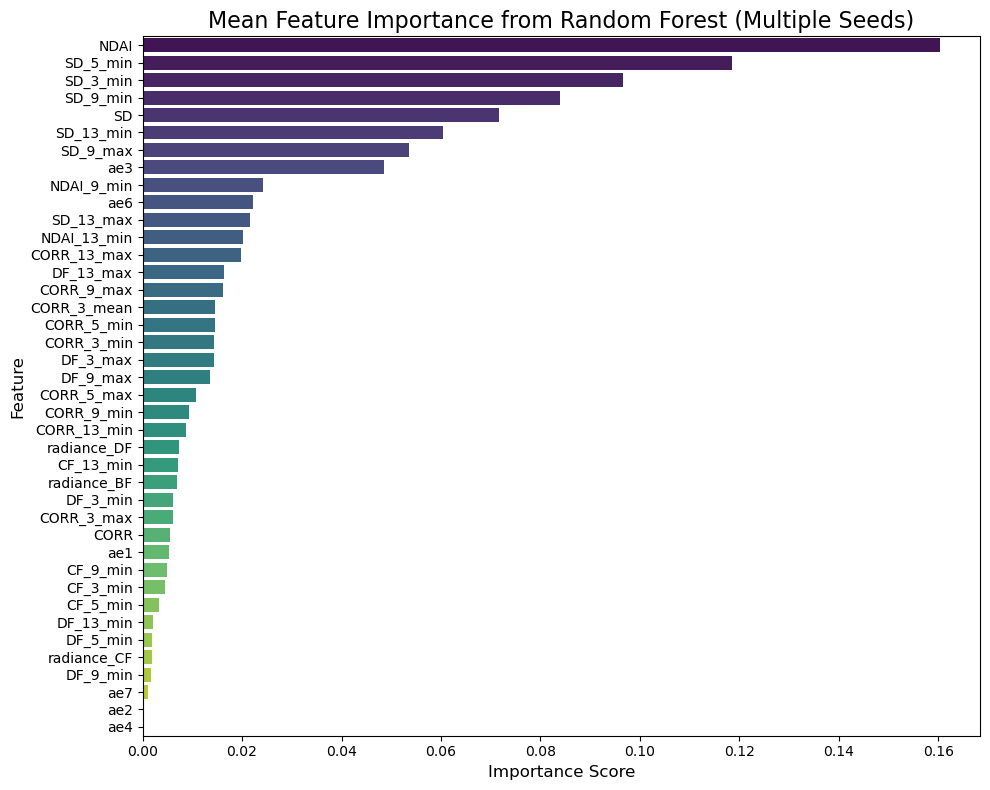

In [19]:
# visualize feature importance
plt.figure(figsize=(10, 8))
sns.barplot(x=importances.values, y=importances.index, palette="viridis")
plt.title("Mean Feature Importance from Random Forest (Multiple Seeds)", fontsize=16)
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.tight_layout()
plt.show()

In [20]:
# top 25 features based on importance
final_features = importances.head(25).index
# add the three expert-selected features back in case they were dropped by the previous steps
final_features = final_features.union(['NDAI', 'SD', 'CORR'])
print("Final selected features:", final_features.tolist()) 

Final selected features: ['CF_13_min', 'CORR', 'CORR_13_max', 'CORR_13_min', 'CORR_3_mean', 'CORR_3_min', 'CORR_5_max', 'CORR_5_min', 'CORR_9_max', 'CORR_9_min', 'DF_13_max', 'DF_3_max', 'DF_9_max', 'NDAI', 'NDAI_13_min', 'NDAI_9_min', 'SD', 'SD_13_max', 'SD_13_min', 'SD_3_min', 'SD_5_min', 'SD_9_max', 'SD_9_min', 'ae3', 'ae6', 'radiance_DF']


In [21]:
X_train = X_train[final_features]
X_val = X_val[final_features]
X_test = X_test[final_features]

## Step 3. Multiple Models

In this section, we will use multiple classifiers to predict the cloud points.

In this part, I will first adopt very basic machine learning models:
+ logistic regression
+ SVM

#### 3.0 Model-oriented Feature selection

For those two models, multicollinearity will make them vulunrable and super stable. 
So I decide to use VIF (variance inflation factor) to do a finer feature selection. 
Although, kernel-based SVM can capture certain nonlinear relationship but due to the high computation cost, a smaller feature set is always a better option.

In [22]:
# vif calculation
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data = pd.DataFrame()
vif_data["feature"] = X_train.columns
vif_data["VIF"] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
print(vif_data.sort_values("VIF", ascending=True))

        feature        VIF
23          ae3   2.513051
0     CF_13_min   5.875637
1          CORR   6.390102
2   CORR_13_max   6.556240
16           SD   7.716744
13         NDAI   7.753482
6    CORR_5_max   7.771284
14  NDAI_13_min   8.748472
3   CORR_13_min   8.789960
18    SD_13_min   9.559915
10    DF_13_max   9.674257
8    CORR_9_max   9.971521
24          ae6  10.116339
17    SD_13_max  10.186271
7    CORR_5_min  10.881043
15   NDAI_9_min  11.139360
9    CORR_9_min  13.462444
5    CORR_3_min  13.462984
25  radiance_DF  14.406757
21     SD_9_max  15.149637
19     SD_3_min  15.955699
12     DF_9_max  16.184535
22     SD_9_min  16.426853
20     SD_5_min  17.280340
11     DF_3_max  21.112988
4   CORR_3_mean  25.943596


Actually, all the features have at least mild multicolinearity problems, with vif >5.

In [23]:
# keep the cols with top 5 lowest VIF values
feature_cols_to_keep = vif_data.sort_values("VIF", ascending=True).head(5)["feature"].tolist()
# keep the expert features and the top 5 features with the lowest VIF
feature_cols_to_keep = list(set(feature_cols_to_keep).union(set(['NDAI', 'SD', 'CORR'])))

print("Features to keep after VIF filtering:", feature_cols_to_keep)

Features to keep after VIF filtering: ['ae3', 'SD', 'CORR', 'NDAI', 'CORR_13_max', 'CF_13_min']


In [24]:
X_train = X_train[feature_cols_to_keep]
X_val = X_val[feature_cols_to_keep]
X_test = X_test[feature_cols_to_keep]

In [25]:
X_train.head()

,ae3,SD,CORR,NDAI,CORR_13_max,CF_13_min
0,-4.516265,-0.009794,-0.609859,2.089605,-2.496632,-3.561652
1,-5.710013,0.363315,-0.556665,2.016691,-2.496632,-3.561652
2,-6.452205,0.196137,-0.461047,2.030392,-2.453885,-3.561652
3,-6.337781,-0.214163,-0.592236,2.005028,-1.862732,-3.561652
4,0.403671,-0.232065,-0.798204,2.055318,-1.862732,-3.561652


### 3.1 Logistic regression

In [26]:
baseline_lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
baseline_lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

For evaluation, we try to include all the classification metrics
+ recall
+ precision
+ f1-score
+ accuracy
+ auc

In [27]:
train_prob_baseline = baseline_lr.predict_proba(X_train)[:, 1]
train_pred_baseline = baseline_lr.predict(X_train)

val_prob_baseline = baseline_lr.predict_proba(X_val)[:, 1]
val_pred_baseline = baseline_lr.predict(X_val)

In [28]:
# evaluate on training set
print("Training Set Performance:")
train_results_baseline = evaluate_model(y_train, train_prob_baseline, pred=train_pred_baseline)
print('train_results_baseline:', train_results_baseline)
# evaluate on validation set
print("\nValidation Set Performance:")
val_results_baseline = evaluate_model(y_val, val_prob_baseline, pred=val_pred_baseline)
print('val_results_baseline:', val_results_baseline)


Training Set Performance:
Evaluation:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     42830
           1       0.98      0.99      0.99     39253

    accuracy                           0.99     82083
   macro avg       0.99      0.99      0.99     82083
weighted avg       0.99      0.99      0.99     82083

Confusion Matrix:
[[42217   613]
 [  472 38781]]
train_results_baseline: {'accuracy': 0.9867816722098364, 'recall': 0.9879754413675388, 'precision': 0.9844392547088389, 'f1_score': 0.9862041781631848, 'auc': 0.9958646566563805}

Validation Set Performance:
Evaluation:
              precision    recall  f1-score   support

           0       0.71      0.99      0.82     33528
           1       0.94      0.36      0.52     21244

    accuracy                           0.74     54772
   macro avg       0.82      0.67      0.67     54772
weighted avg       0.80      0.74      0.71     54772

Confusion Matrix:
[[33045   483]
 [1358

It looks like the baseline model is heavily overfitting. 

F1-score on train is 0.99 while it is 0.54 on validation set, which means overftting and distribution shift.

Especially, the recall in validation set is too low with 0.38, which implies the model is too conservative in predicting cloud class. It implies the threshold tuning is necessary too.

#### Hyperparameter tuning

Since the logistic regression is not computationally expensive. Using the gridsearch can help us find the best hyperparameter combination.

Since the baseline model performs poorly in validation set in case of recall, so the hyperparameter tuning will focus on improving the f1-score.

In [29]:
best_model = None
best_score = 0

lr_results = []
for C in [0.01, 0.1, 1]:
    for cw in [None, "balanced", {0:1,1:2}]:
        model = LogisticRegression(
            C=C,
            penalty="elasticnet",
            solver="saga",
            l1_ratio=0.5,
            class_weight=cw,
            max_iter=1000
        )

        model.fit(X_train, y_train)
        val_prob = model.predict_proba(X_val)[:,1]

        # threshold tuning inside
        for t in np.linspace(0.2, 0.6, 20):
            y_pred = (val_prob >= t).astype(int)
            f1 = f1_score(y_val, y_pred)

            if f1 > best_score:
                best_score = f1
                best_model = (model, t)
        # save the model parameters and threshold that give the best F1 score on the validation set
        lr_results.append({
            "C": C,
            "class_weight": cw,
            "threshold": t,
            "f1_score": f1
        })

print("Best F1:", best_score)
print("Best Model Parameters:", best_model[0].get_params())
print("Best Threshold:", best_model[1])


Best F1: 0.6577463500868664
Best Model Parameters: {'C': 0.01, 'class_weight': {0: 1, 1: 2}, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': 0.5, 'max_iter': 1000, 'n_jobs': None, 'penalty': 'elasticnet', 'random_state': None, 'solver': 'saga', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}
Best Threshold: 0.2


####  Best logsic regression

In [30]:
# use the best model to predict on the test set
best_lr_model = best_model[0]
best_lr_threshold = best_model[1]

test_prob_lr = best_lr_model.predict_proba(X_test)[:, 1]
test_pred_lr = (test_prob_lr >= best_lr_threshold).astype(int)
print("Test Set Performance:")
test_results = evaluate_model( y_test, test_prob_lr, threshold=best_lr_threshold, pred=test_pred_lr)
print('test_results:', test_results)

Test Set Performance:
Evaluation:
              precision    recall  f1-score   support

           0       0.79      0.93      0.86     50358
           1       0.71      0.40      0.51     20468

    accuracy                           0.78     70826
   macro avg       0.75      0.67      0.69     70826
weighted avg       0.77      0.78      0.76     70826

Confusion Matrix:
[[46967  3391]
 [12196  8272]]
test_results: {'accuracy': 0.7799254511055262, 'recall': 0.40414305256986516, 'precision': 0.7092514790362685, 'f1_score': 0.514892160219103, 'auc': 0.7428424567258871}


In [31]:
# result summary on training, validation
lr_train_results = evaluate_model(y_train, best_lr_model.predict_proba(X_train)[:, 1], threshold=best_lr_threshold)
lr_val_results = evaluate_model(y_val, best_lr_model.predict_proba(X_val)[:, 1], threshold=best_lr_threshold)

Evaluation:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     42830
           1       0.96      1.00      0.98     39253

    accuracy                           0.98     82083
   macro avg       0.98      0.98      0.98     82083
weighted avg       0.98      0.98      0.98     82083

Confusion Matrix:
[[41027  1803]
 [  172 39081]]
Evaluation:
              precision    recall  f1-score   support

           0       0.76      0.98      0.85     33528
           1       0.93      0.51      0.66     21244

    accuracy                           0.79     54772
   macro avg       0.85      0.74      0.76     54772
weighted avg       0.83      0.79      0.78     54772

Confusion Matrix:
[[32753   775]
 [10454 10790]]


Even after hyper-parameter tuning, the logistic regression is still over-fitting.

In [32]:
# save all the results
lr_results_summary = {
    "train_results": lr_train_results,
    "val_results": lr_val_results,
    "test_results": test_results,
    "selected_features": feature_cols_to_keep,
    "tuning_df": pd.DataFrame(lr_results),
    "best_model_params": best_lr_model.get_params(),
    "best_model_threshold": best_lr_threshold,
    "best_model_score": best_score,
    "data_params": {
        "scaler_type": 'standard',
        "remove_outliers": False,
        "outlier_threshold": 3.0
    },
    "feature_selection_used": True,
    "feature_selection_params": {
        "high_corr_threshold": 0.95,
        "variance_threshold": 1e-5,
        "mutual_info_top_k": 40,
        "rf_top_k": 25,
        'vif_top_k': 5
    }
}
save_pipeline_results(lr_results_summary, output_dir="../results/logistic_main_run")

#### Evaluation

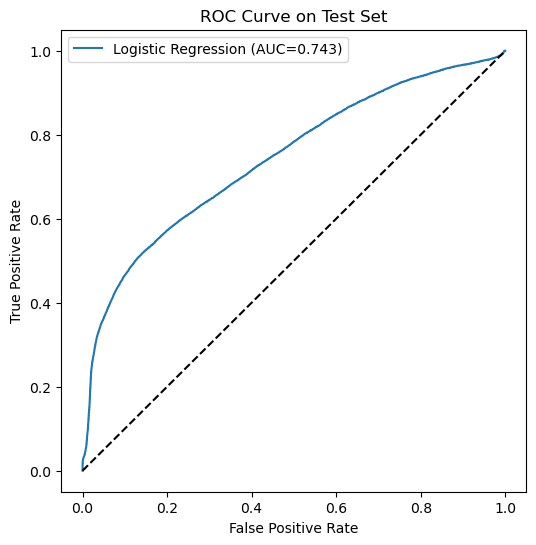

In [33]:
# AUC-ROC curve
fpr, tpr, thresholds = roc_curve(y_test, test_prob_lr)
test_auc = roc_auc_score(y_test, test_prob_lr)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC={test_auc:.3f})")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve on Test Set")
plt.legend()
plt.show()

In [34]:
# If you trained LR directly on a pandas DataFrame with selected columns:
feature_names = feature_cols_to_keep
lr_coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": best_lr_model.coef_.ravel()
}).sort_values("coefficient", key=abs, ascending=False)

In [35]:
print(lr_coef_df)

       feature  coefficient
3         NDAI     4.212835
0          ae3    -3.980622
5    CF_13_min    -0.390825
1           SD     0.384065
2         CORR    -0.200048
4  CORR_13_max     0.000000


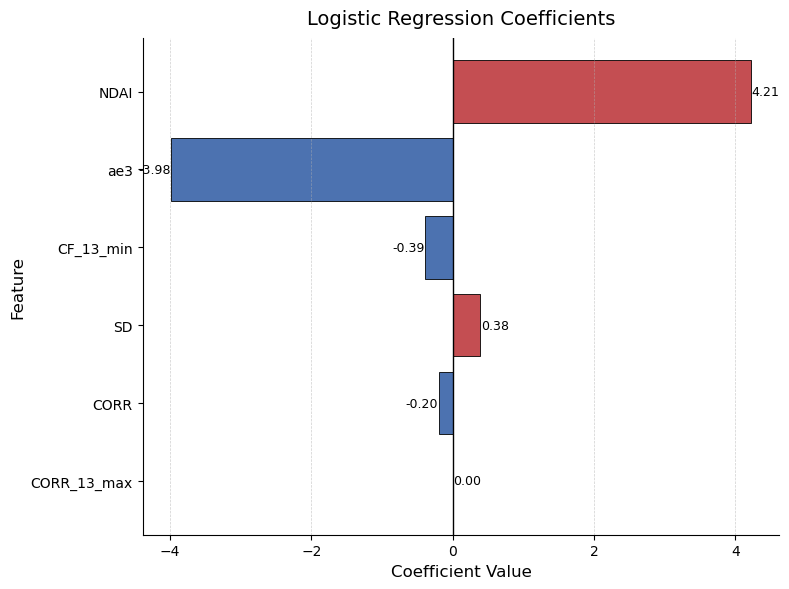

In [36]:
# Sort coefficients by absolute value
top_coef = lr_coef_df.reindex(
    lr_coef_df["coefficient"].abs().sort_values(ascending=False).index
).copy()

# Direction
top_coef["direction"] = np.where(top_coef["coefficient"] >= 0, "Positive", "Negative")

# More publication-friendly colors (muted, colorblind-safe)
color_map = {"Positive": "#C44E52", "Negative": "#4C72B0"}
colors = top_coef["direction"].map(color_map)

# Figure
plt.figure(figsize=(8, 6))  # smaller, tighter

bars = plt.barh(
    top_coef["feature"],
    top_coef["coefficient"],
    color=colors,
    edgecolor="black",
    linewidth=0.6
)

# Vertical zero line
plt.axvline(0, color="black", linewidth=1)

# Subtle grid (important for readability)
plt.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.6)

# Invert y-axis (largest on top)
plt.gca().invert_yaxis()

# Labels and title (clean style)
plt.xlabel("Coefficient Value", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.title("Logistic Regression Coefficients", fontsize=14, pad=10)

# Optional: annotate values (very useful for report)
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + (0.01 if width >= 0 else -0.01),
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}",
        va="center",
        ha="left" if width >= 0 else "right",
        fontsize=9
    )

# Remove top/right spines (publication style)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.savefig("../figs/lr_coefficients.png", dpi=300, bbox_inches='tight')  # save high-res figure for report

plt.tight_layout()
plt.show()


Comment:

Based on the VIF selection, we can find `ae3` is not linearly correlted with other features wih value at round 3. One intuition behind that is this latent factor captures some new pattern which are not captured via existing features.

As for the influence direction, `SD` and `NDAI` both have positive impacts in predicting cloud class, which is aligned with domain knowledge. 

In [37]:
# error analysis
lr_error_df = test_df[["y_coord", "x_coord", "label"]].copy()
lr_error_df["pred_prob"] = test_prob_lr
lr_error_df["pred_label"] = test_pred_lr

def error_type(row):
    if row["label"] == 1 and row["pred_label"] == 1:
        return "TP"
    elif row["label"] == 0 and row["pred_label"] == 0:
        return "TN"
    elif row["label"] == 0 and row["pred_label"] == 1:
        return "FP"
    else:
        return "FN"

lr_error_df["error_type"] = lr_error_df.apply(error_type, axis=1)
lr_error_df.head()

,y_coord,x_coord,label,pred_prob,pred_label,error_type
1,2.0,71.0,1,1.0,1,TP
2,2.0,72.0,1,1.0,1,TP
3,2.0,73.0,1,1.0,1,TP
4,2.0,74.0,1,1.0,1,TP
5,2.0,75.0,1,1.0,1,TP


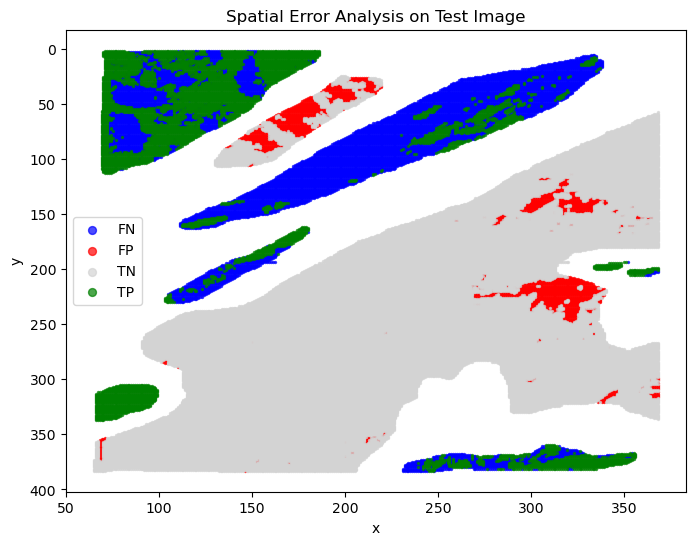

In [38]:
color_map = {"TP":"green", "TN":"lightgray", "FP":"red", "FN":"blue"}

plt.figure(figsize=(8,6))
for etype, g in lr_error_df.groupby("error_type"):
    plt.scatter(
        g["x_coord"], g["y_coord"],
        s=2, alpha=0.7,
        label=etype,
        c=color_map[etype]
    )

plt.gca().invert_yaxis()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Spatial Error Analysis on Test Image")
plt.legend(markerscale=4)
plt.show()

Comment:

The misclassified points usually gather together. 
We can find the FN points concentrate, which means some spatial pattern in cloud is not well-discovered. 

### 3.2 SVM

In [39]:
# first try the linearSVM with default parameters as the baseline model, and then we will do hyperparameter tuning for SVM in the next steps.
baseline_svm = svm.LinearSVC(
        C=1,
        class_weight="balanced",
        max_iter=10000,
        random_state=42
    )
baseline_svm.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo 

In [40]:
train_score_svm_baseline = baseline_svm.decision_function(X_train)
train_pred_svm_baseline = baseline_svm.predict(X_train)

val_score_svm_baseline = baseline_svm.decision_function(X_val)
val_pred_svm_baseline = baseline_svm.predict(X_val)

In [41]:
# evaluate on training set
print("Training Set Performance:")
train_results_baseline_svm = evaluate_model( y_train, prob=train_score_svm_baseline, pred=train_pred_svm_baseline)
print('train_results_baseline_svm:', train_results_baseline_svm)
# evaluate on validation set
print("\nValidation Set Performance:")
val_results_baseline_svm = evaluate_model( y_val, prob=val_score_svm_baseline, pred=val_pred_svm_baseline)
print('val_results_baseline_svm:', val_results_baseline_svm)

Training Set Performance:
Evaluation:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99     42830
           1       0.98      0.99      0.99     39253

    accuracy                           0.99     82083
   macro avg       0.99      0.99      0.99     82083
weighted avg       0.99      0.99      0.99     82083

Confusion Matrix:
[[42090   740]
 [  417 38836]]
train_results_baseline_svm: {'accuracy': 0.9859045112873555, 'recall': 0.9893766081573383, 'precision': 0.9813017990701435, 'f1_score': 0.985322660442223, 'auc': 0.995641403228643}

Validation Set Performance:
Evaluation:
              precision    recall  f1-score   support

           0       0.71      0.99      0.82     33528
           1       0.94      0.35      0.51     21244

    accuracy                           0.74     54772
   macro avg       0.82      0.67      0.67     54772
weighted avg       0.80      0.74      0.70     54772

Confusion Matrix:
[[33059   469]
 [13

**Comment**:

The performance of linear SVM model is very similar as the logsictic regression which gives us the inituition that the relationship is not simply linear and we should try **non-linear** kernels.

#### Hyperparamter tuning

With rbf kernel, the two main parameters I choose to tune is:

1. `C`: it controls the trade-off between margin width and classification error.

    `C` determines how much we punish mistakes. Small `C` means we allows more misclassification and priortizes large margin.

2. `Gamma`: Gamma appears in the RBF kernel:

    $$K(x_i,x_j) = \exp \{-\gamma \| x_i-x_j\|^2\}$$

    large `Gamma` means the influence radius is very small and each pointss only affects nearby region, leading to very wiggly boundary.

In [42]:
def tune_svm_model(X_train, y_train, X_val, y_val, param_grid):
    # linear kernel grid
    if param_grid is None:
        param_grid = [
            {"kernel": "linear", "C": 0.1, "class_weight": "balanced"},
            {"kernel": "linear", "C": 1, "class_weight": "balanced"},
            {"kernel": "linear", "C": 0.1, "class_weight": {0: 1, 1: 2}},
        ]

    best_model = None
    best_score = -1
    best_threshold = 0.0
    best_params = None
    records = []

    for params in param_grid:
        model = svm.SVC(
            **params,
            probability=False,   # much faster
            random_state=42
        )

        model.fit(X_train, y_train)
        val_score = model.decision_function(X_val)

        # threshold tuning on decision scores
        threshold_grid = np.percentile(val_score, [20, 35, 50, 65, 80])

        for t in threshold_grid:
            y_pred = (val_score >= t).astype(int)
            f1 = f1_score(y_val, y_pred)

            if f1 > best_score:
                best_score = f1
                best_model = model
                best_threshold = t
                best_params = params
            records.append((params, t, f1))
    records_df = pd.DataFrame(records, columns=["params", "threshold", "f1_score"])

    return best_model, best_params, best_threshold, best_score, records_df

In [43]:
linear_param_grid = [
            {"kernel": "linear", "C": 0.1, "class_weight": "balanced"},
            {"kernel": "linear", "C": 1, "class_weight": "balanced"},
            {"kernel": "linear", "C": 0.1, "class_weight": {0: 1, 1: 2}},
]

In [44]:
# best_svm_model, best_svm_params, best_svm_threshold, best_svm_score = tune_svm_model(X_train, y_train, X_val, y_val, param_grid=linear_param_grid)
# print("Best SVM F1 Score:", best_svm_score)
# print("Best SVM Parameters:", best_svm_params)
# print("Best SVM Threshold:", best_svm_threshold)

Based on the linearSVM-based result, we tuned the paramter with rbf kernel

In [45]:
rbf_candidates = [
    {"kernel": "rbf", "C": 0.1, "gamma": "scale", "class_weight": {0: 1, 1: 2}},
    {"kernel": "rbf", "C": 1,   "gamma": "scale", "class_weight": {0: 1, 1: 2}},
    {"kernel": "rbf", "C": 0.1, "gamma": 0.1,     "class_weight": {0: 1, 1: 2}},
    {"kernel": "rbf", "C": 1,   "gamma": 0.1,     "class_weight": {0: 1, 1: 2}},
]
best_svm_model_rbf, best_svm_params_rbf, best_svm_threshold_rbf, best_svm_score_rbf, svm_tuning_df = tune_svm_model(X_train, y_train, X_val, y_val, param_grid=rbf_candidates)
print("Best RBF SVM F1 Score:", best_svm_score_rbf)
print("Best RBF SVM Parameters:", best_svm_params_rbf)
print("Best RBF SVM Threshold:", best_svm_threshold_rbf)

Best RBF SVM F1 Score: 0.8414410847726036
Best RBF SVM Parameters: {'kernel': 'rbf', 'C': 0.1, 'gamma': 0.1, 'class_weight': {0: 1, 1: 2}}
Best RBF SVM Threshold: -1.3061927694189417


#### Best SVM

In [46]:
best_svm_model_final = svm.SVC(
    **best_svm_params_rbf,
    probability=True,
    random_state=42
)
best_svm_model_final.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.1
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.","{0: 1, 1: 2}"
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [47]:
train_prob_svm = best_svm_model_final.predict_proba(X_train)[:, 1]
train_pred_svm = best_svm_model_final.predict(X_train)

val_prob_svm = best_svm_model_final.predict_proba(X_val)[:, 1]
val_pred_svm = best_svm_model_final.predict(X_val)

In [48]:
test_prob_svm = best_svm_model_final.predict_proba(X_test)[:, 1]
test_pred_svm = best_svm_model_final.predict(X_test)

In [49]:
# evaluate on training set
print("Training Set Performance:")
train_results_best_svm = evaluate_model(y_train, prob=train_prob_svm, pred=train_pred_svm)
print('train_results_best_svm:', train_results_best_svm)
# evaluate on validation set
print("\nValidation Set Performance:")
val_results_best_svm = evaluate_model(y_val, prob=val_prob_svm, pred=val_pred_svm)
print('val_results_best_svm:', val_results_best_svm)
# evaluate on test set
print("\nTest Set Performance:")    
test_results_best_svm = evaluate_model(y_test, prob=test_prob_svm, pred=test_pred_svm)
print('test_results_best_svm:', test_results_best_svm)  

Training Set Performance:
Evaluation:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     42830
           1       0.99      1.00      0.99     39253

    accuracy                           0.99     82083
   macro avg       0.99      0.99      0.99     82083
weighted avg       0.99      0.99      0.99     82083

Confusion Matrix:
[[42501   329]
 [  125 39128]]
train_results_best_svm: {'accuracy': 0.9944690130721343, 'recall': 0.9968155300231829, 'precision': 0.9916618090579619, 'f1_score': 0.9942319908524965, 'auc': 0.9992844261755218}

Validation Set Performance:
Evaluation:
              precision    recall  f1-score   support

           0       0.74      0.98      0.84     33528
           1       0.92      0.46      0.61     21244

    accuracy                           0.78     54772
   macro avg       0.83      0.72      0.73     54772
weighted avg       0.81      0.78      0.75     54772

Confusion Matrix:
[[32695   833]
 [1145

In [50]:
# save model summary for SVM

svm_results_summary = {
    "train_results": train_results_best_svm,
    "val_results": val_results_best_svm,
    "test_results": test_results_best_svm,
    "selected_features": feature_cols_to_keep,
    "tuning_df": pd.DataFrame(svm_tuning_df),
    "best_model_params": best_svm_model_final.get_params(),
    "best_model_threshold": best_svm_threshold_rbf,
    "best_model_score": best_svm_score_rbf,
    "data_params": {
        "scaler_type": 'standard',
        "remove_outliers": False,
        "outlier_threshold": 3.0
    },
    "feature_selection_used": True,
    "feature_selection_params": {
        "high_corr_threshold": 0.95,
        "variance_threshold": 1e-5,
        "mutual_info_top_k": 40,
        "rf_top_k": 25,
        'vif_top_k': 5
    }
}
save_pipeline_results(svm_results_summary, output_dir="../results/svm_main_run")

#### Evaluation

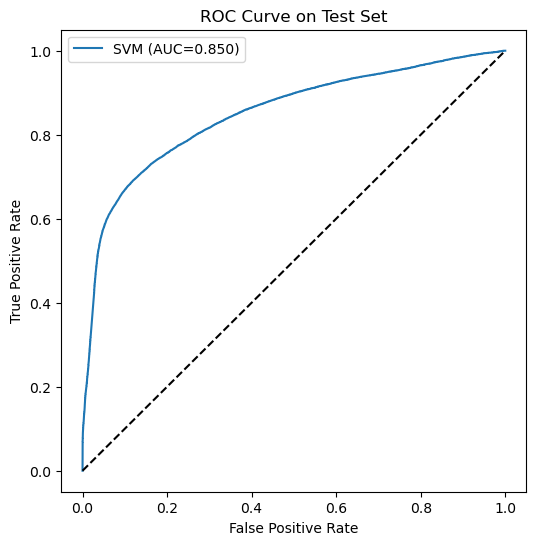

In [51]:
# AUC-ROC curve
fpr, tpr, thresholds = roc_curve(y_test, test_prob_svm)
test_auc = roc_auc_score(y_test, test_prob_svm)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"SVM (AUC={test_auc:.3f})")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve on Test Set")
plt.legend()
plt.show()

#### Feature importance

Since I basically choose the nonlieanr kernel, SVM does not have interpretable coefficients. 

Permutation importance is the best way to capture the feature importance in the nonlinear SVM, but it takes a lot of time and cannot be very interpretable without the exact the influence direction.

In [52]:
# permutation feature importance for the best SVM model
from sklearn.inspection import permutation_importance

svm_feature_importance_data = permutation_importance(
    best_svm_model_final,
    X_val,
    y_val,
    n_repeats=5,          # keep small for speed
    scoring="f1",
    random_state=42
)

svm_importances = svm_feature_importance_data.importances_mean

In [53]:
importances_std = svm_feature_importance_data.importances_std
svm_feature_importance = pd.DataFrame({
    "feature": X_val.columns,
    "importance_mean": svm_importances,
    "importance_std": importances_std
}).sort_values(by="importance_mean", ascending=False)

print(svm_feature_importance)

       feature  importance_mean  importance_std
0          ae3         0.122915        0.001167
3         NDAI         0.079995        0.001248
1           SD         0.042901        0.001051
5    CF_13_min         0.003517        0.000551
2         CORR        -0.020410        0.000819
4  CORR_13_max        -0.043002        0.001036


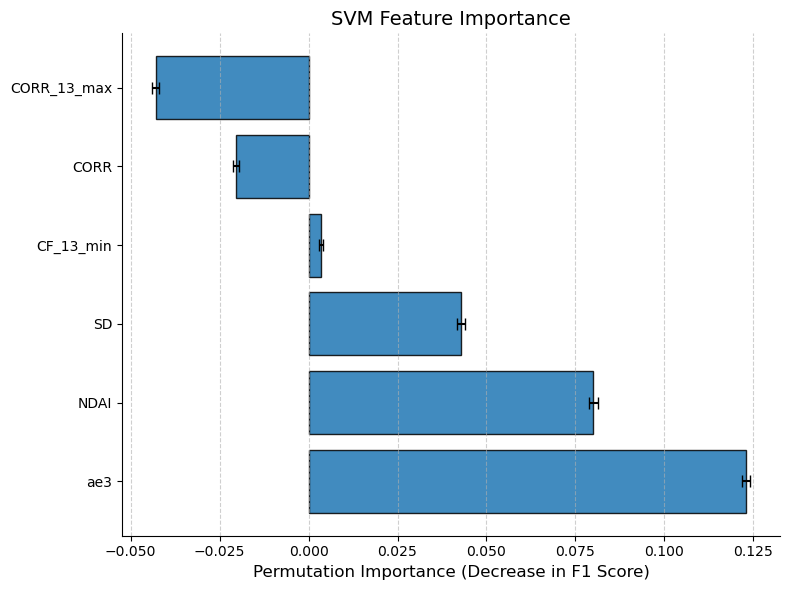

In [54]:
df_plot = svm_feature_importance.sort_values(
    by="importance_mean", ascending=True
)

plt.figure(figsize=(8, 6))

bars = plt.barh(
    df_plot["feature"],
    df_plot["importance_mean"],
    xerr=df_plot["importance_std"],
    capsize=4,
    alpha=0.85,
    edgecolor="black"
)

# ---- styling ----
plt.xlabel("Permutation Importance (Decrease in F1 Score)", fontsize=12)
plt.title("SVM Feature Importance", fontsize=14)

plt.gca().invert_yaxis()

# grid for readability
plt.grid(axis="x", linestyle="--", alpha=0.6)

# remove top/right spines (clean look)
for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.savefig("../figs/svm_feature_importance.png", dpi=300, bbox_inches='tight')  # save high-res figure for report
plt.show()

In [55]:
svm_error_df = test_df[["y_coord", "x_coord", "label"]].copy()
svm_error_df["pred_prob"] = test_prob_svm
svm_error_df["pred_label"] = test_pred_svm

def error_type(row):
    if row["label"] == 1 and row["pred_label"] == 1:
        return "TP"
    elif row["label"] == 0 and row["pred_label"] == 0:
        return "TN"
    elif row["label"] == 0 and row["pred_label"] == 1:
        return "FP"
    else:
        return "FN"

svm_error_df["error_type"] = svm_error_df.apply(error_type, axis=1)
svm_error_df.head()

,y_coord,x_coord,label,pred_prob,pred_label,error_type
1,2.0,71.0,1,0.935452,1,TP
2,2.0,72.0,1,0.904660,1,TP
3,2.0,73.0,1,0.916278,1,TP
4,2.0,74.0,1,0.997146,1,TP
5,2.0,75.0,1,0.992509,1,TP


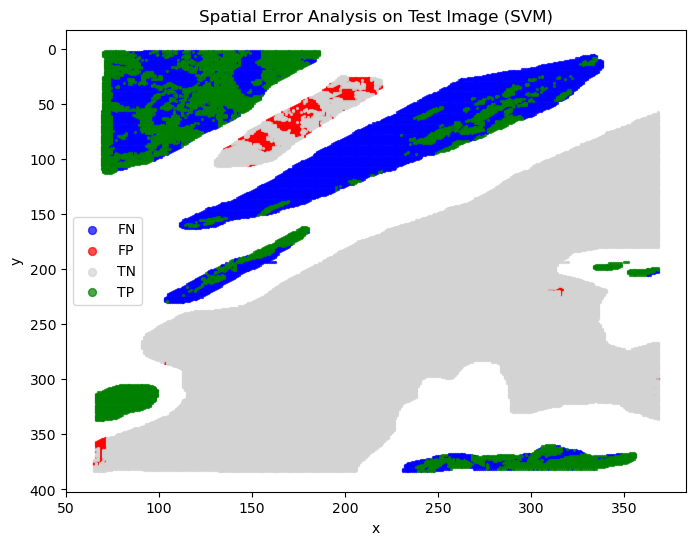

In [56]:
color_map = {"TP":"green", "TN":"lightgray", "FP":"red", "FN":"blue"}

plt.figure(figsize=(8,6))
for etype, g in svm_error_df.groupby("error_type"):
    plt.scatter(
        g["x_coord"], g["y_coord"],
        s=2, alpha=0.7,
        label=etype,
        c=color_map[etype]
    )

plt.gca().invert_yaxis()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Spatial Error Analysis on Test Image (SVM)")
plt.legend(markerscale=4)
plt.show()

Remark:

After removing the unlabeled points, we mark the cloud points with FN, FP, TN, TP in the test image. Interestingly, we find the false positive points are concentrated near cloud edges. Relatively, we have little false negative points in the cloud regions. 
